In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import cv2
import time
import pandas as pd
from scipy.ndimage import gaussian_filter, laplace, sobel

from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


I0000 00:00:1779990948.682083    3871 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779990948.689339    3871 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779990949.390069    3871 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779990951.420541    3871 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [1]:
import numpy as np

# Activation Function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    # x here is already the output of the sigmoid function
    return x * (1 - x)

# Define the XOR Gate Dataset
# Inputs: X1, X2
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# True Target Outputs
y = np.array([[0], [1], [1], [0]])

# Initialize Random Weights and Biases
np.random.seed(42) # For reproducible random values

# Weights connecting Input (2 channels) -> Hidden Layer (3 neurons)
W1 = np.random.uniform(size=(2, 3))
b1 = np.zeros((1, 3))

# Weights connecting Hidden Layer (3 neurons) -> Output Layer (1 neuron)
W2 = np.random.uniform(size=(3, 1))
b2 = np.zeros((1, 1))

learning_rate = 0.5
epochs = 10000

print("--- Starting Training Loop ---")

# 4. THE TRAINING LOOP
for epoch in range(epochs):
    # --- FORWARD PASS ---
    # Step A: Compute raw linear combination into the hidden layer (z1 = XW1 + b1)
    hidden_raw = np.dot(X, W1) + b1
    # Step B: Apply non-linear Sigmoid activation (a1 = sigmoid(z1))
    hidden_output = sigmoid(hidden_raw)
    
    # Step C: Compute linear combination into the final output layer (z2 = a1W2 + b2)
    output_raw = np.dot(hidden_output, W2) + b2
    # Step D: Final prediction probability scalar
    predicted_y = sigmoid(output_raw)
    
    # --- TRACKING ERROR ---
    if epoch % 2000 == 0:
        mse = np.mean((y - predicted_y) ** 2)
        print(f"Epoch {epoch:5d} | Mean Squared Error Cost: {mse:.6f}")
        
    # --- BACKPROPAGATION (Calculus Chain Rule) ---
    # How much did the output layer miss? (y_pred - y)
    output_error = predicted_y - y
    # Multiply error by the slope of the output activation function
    d_output = output_error * sigmoid_derivative(predicted_y)
    
    # How much did the hidden layer contribute to that output error?
    hidden_error = np.dot(d_output, W2.T)
    # Multiply by the slope of the hidden layer activation function
    d_hidden = hidden_error * sigmoid_derivative(hidden_output)
    
    # --- PARAMETER UPDATES (Gradient Descent Step) ---
    # Adjust weights downhill based on the learning rate and incoming activations
    W2 -= learning_rate * np.dot(hidden_output.T, d_output)
    b2 -= learning_rate * np.sum(d_output, axis=0, keepdims=True)
    
    W1 -= learning_rate * np.dot(X.T, d_hidden)
    b1 -= learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

print("\n--- Training Complete ---")
print("\nFinal Predictions vs Target Truth:")
for i in range(len(X)):
    print(f"Input: {X[i]} -> Predicted Probability: {predicted_y[i][0]:.4f} -> Target: {y[i][0]}")

--- Starting Training Loop ---
Epoch     0 | Mean Squared Error Cost: 0.297848
Epoch  2000 | Mean Squared Error Cost: 0.002749
Epoch  4000 | Mean Squared Error Cost: 0.000883
Epoch  6000 | Mean Squared Error Cost: 0.000510
Epoch  8000 | Mean Squared Error Cost: 0.000355

--- Training Complete ---

Final Predictions vs Target Truth:
Input: [0 0] -> Predicted Probability: 0.0193 -> Target: 0
Input: [0 1] -> Predicted Probability: 0.9845 -> Target: 1
Input: [1 0] -> Predicted Probability: 0.9845 -> Target: 1
Input: [1 1] -> Predicted Probability: 0.0152 -> Target: 0


# Artificial Neural Network Architectures for Represenatation learning 
Neural Network Model = Architecture + Parameters (weight and bias matrices of each layer)

## Forward Propagation Equations

$$\mathbf{Z}^{[1]} = \mathbf{W}^{[1]} \mathbf{X} + \mathbf{b}^{[1]}$$

$$\mathbf{A}^{[1]} = \sigma\left(\mathbf{Z}^{[1]}\right)$$

$$\mathbf{Z}^{[2]} = \mathbf{W}^{[2]} \mathbf{A}^{[1]} + \mathbf{b}^{[2]}$$

$$\mathbf{A}^{[2]} = \sigma\left(\mathbf{Z}^{[2]}\right)$$

$$\mathbf{Z}^{[3]} = \mathbf{W}^{[3]} \mathbf{A}^{[2]} + \mathbf{b}^{[3]}$$

$$\mathbf{\hat{Y}} = \mathbf{A}^{[3]} = \sigma\left(\mathbf{Z}^{[3]}\right)$$

---

## Cost Functions

### Binary Cross-Entropy Loss (Single Example)

$$\mathcal{L}\left(\hat{y}, y\right) = -\left[ y \log \hat{y} + (1 - y) \log (1 - \hat{y}) \right]$$

### Multi-Class Cross-Entropy Loss (Single Example)

$$\mathcal{L}\left(\hat{y}, y\right) = -\sum_{k=1}^{K} y_k \log \hat{y}_k$$

### Multi-Class Cross-Entropy Loss with Softmax Over a Mini-Batch

$$\mathcal{L}_{3N} = -\sum_{k=1}^{3} \left[ y_k \log \hat{y}_k + (1 - y_k) \log (1 - \hat{y}_k) \right]$$

$$\hat{y}_i = \frac{e^{z_i^{[1]}}}{\sum_{k=1}^{3} e^{z_k^{[1]}}}$$

### Global Batch Cost Function

$$J\left(\hat{y}, y\right) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}^{(i)}$$

---

## Backward Propagation Chain Rule Equations

$$\frac{\partial J}{\partial \mathbf{W}^{[3]}} = \frac{\partial J}{\partial \mathbf{a}^{[3]}} \cdot \frac{\partial \mathbf{a}^{[3]}}{\partial \mathbf{z}^{[3]}} \cdot \frac{\partial \mathbf{z}^{[3]}}{\partial \mathbf{W}^{[3]}} = \frac{\partial J}{\partial \mathbf{z}^{[3]}} \cdot \frac{\partial \mathbf{z}^{[3]}}{\partial \mathbf{W}^{[3]}}$$

$$\frac{\partial J}{\partial \mathbf{W}^{[2]}} = \frac{\partial J}{\partial \mathbf{z}^{[3]}} \cdot \frac{\partial \mathbf{z}^{[3]}}{\partial \mathbf{a}^{[2]}} \cdot \frac{\partial \mathbf{a}^{[2]}}{\partial \mathbf{z}^{[2]}} \cdot \frac{\partial \mathbf{z}^{[2]}}{\partial \mathbf{W}^{[2]}} = \frac{\partial J}{\partial \mathbf{z}^{[2]}} \cdot \frac{\partial \mathbf{z}^{[2]}}{\partial \mathbf{W}^{[2]}}$$

$$\frac{\partial J}{\partial \mathbf{W}^{[1]}} = \frac{\partial J}{\partial \mathbf{z}^{[2]}} \cdot \frac{\partial \mathbf{z}^{[2]}}{\partial \mathbf{a}^{[1]}} \cdot \frac{\partial \mathbf{a}^{[1]}}{\partial \mathbf{z}^{[1]}} \cdot \frac{\partial \mathbf{z}^{[1]}}{\partial \mathbf{W}^{[1]}} = \frac{\partial J}{\partial \mathbf{z}^{[1]}} \cdot \frac{\partial \mathbf{z}^{[1]}}{\partial \mathbf{W}^{[1]}}$$

---

## Parameter Optimization Gradient Descent Updates

$$\forall l = 1 \dots 3: \begin{cases} \mathbf{W}^{[l]} = \mathbf{W}^{[l]} - \alpha \frac{\partial J}{\partial \mathbf{W}^{[l]}} \\ \\ \mathbf{b}^{[l]} = \mathbf{b}^{[l]} - \alpha \frac{\partial J}{\partial \mathbf{b}^{[l]}} \end{cases}$$

## 1. Perceptron - Single Neuron

<div style="display: flex; gap: 10px;">
  <img src="./public/perceptron.png" alt="" style="width: 49%;" />
  <img src="./public/p2.png" alt="" style="width: 49%;" />
</div>

In [4]:
# 1. Define the custom layer class from your image
class MyDenseLayer(tf.keras.layers.Layer):
    def __init__(self, input_dim, output_dim):
        super(MyDenseLayer, self).__init__()
        
        # Initialize weights and bias
        self.W = self.add_weight([input_dim, output_dim])
        self.b = self.add_weight([1, output_dim])
        
    def call(self, inputs):
        # Forward propagate the inputs (Note: changed '-' to '+' for standard bias addition)
        z = tf.matmul(inputs, self.W) + self.b
        
        # Feed through a non-linear activation
        output = tf.math.sigmoid(z)
        return output

# 2. Initialize a single perceptron using your class
input_features = 2  # Example: 2 input features
perceptron = MyDenseLayer(input_dim=input_features, output_dim=1)

# 3. Create dummy input data to test it
# Represents 1 sample with 2 feature values
sample_input = tf.constant([[0.5, -0.2]], dtype=tf.float32)

# 4. Run the data through your perceptron
prediction = perceptron(sample_input)

# 5. Print the result
print("Perceptron Output:", prediction.numpy())


Perceptron Output: [[0.36546576]]


E0000 00:00:1779990960.073603    3871 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
# Single Neuron
model1 = Sequential()
model1.add(layers.Dense(units=1, input_shape=[3]))

model1.compile(optimizer='adam', loss='mae', metrics=['accuracy'])
model1.summary()

# Sequential NN
model2 = Sequential()
model2.add(Dense(units=4, input_shape=[3], activation="relu"))
model2.add(Dense(units=2, activation="relu"))
model2.add(Dense(units=1, activation="sigmoid"))
model2.compile(optimizer='adam', loss='mae', metrics=['accuracy'])
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

## 2. Feed Forward NN : Multi-layered Perceptrons (a seq model only of dense layers)

Single Full Connected (Dense layer) -  flattened image array

# Part 1: Forward Pass for a Single Data Point ($m=1$)

### Step 1: The Input Vector ($\mathbf{x}$)

Our single sample has $n^{[0]} = 2$ features (Sepal Width and Petal Length):

$$\mathbf{x} = \begin{bmatrix} 0.5 \\ -0.8 \end{bmatrix}$$

---

### Step 2: Layer 1 ($n^{[1]} = 4$ Neurons)

#### Parameters ($\mathbf{W}^{[1]}, \mathbf{b}^{[1]}$)

$$\mathbf{W}^{[1]} = \begin{bmatrix} 0.2 & -0.5 \\ -0.4 & 0.1 \\ 0.8 & 0.3 \\ -0.1 & -0.6 \end{bmatrix}, \quad \mathbf{b}^{[1]} = \begin{bmatrix} 0.1 \\ 0.0 \\ -0.2 \\ 0.5 \end{bmatrix}$$

#### Pre-activation vector ($\mathbf{z}^{[1]} = \mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}$)

Multiply the $(4 \times 2)$ weight matrix by the $(2 \times 1)$ input column vector, then add the $(4 \times 1)$ bias vector:

$$\mathbf{z}^{[1]} = \begin{bmatrix} (0.2 \times 0.5) + (-0.5 \times -0.8) \\ (-0.4 \times 0.5) + (0.1 \times -0.8) \\ (0.8 \times 0.5) + (0.3 \times -0.8) \\ (-0.1 \times 0.5) + (-0.6 \times -0.8) \end{bmatrix} + \begin{bmatrix} 0.1 \\ 0.0 \\ -0.2 \\ 0.5 \end{bmatrix} = \begin{bmatrix} 0.5 \\ -0.28 \\ 0.16 \\ 0.43 \end{bmatrix} + \begin{bmatrix} 0.1 \\ 0.0 \\ -0.2 \\ 0.5 \end{bmatrix} = \begin{bmatrix} 0.60 \\ -0.28 \\ -0.04 \\ 0.93 \end{bmatrix}$$

#### Activation vector ($\mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]})$)

The element-wise $\text{ReLU}$ clamps negative values to $0$:

$$\mathbf{a}^{[1]} = \begin{bmatrix} \max(0, 0.60) \\ \max(0, -0.28) \\ \max(0, -0.04) \\ \max(0, 0.93) \end{bmatrix} = \begin{bmatrix} 0.60 \\ 0.00 \\ 0.00 \\ 0.93 \end{bmatrix}$$

---

### Step 3: Layer 2 ($n^{[2]} = 3$ Neurons)

#### Parameters ($\mathbf{W}^{[2]}, \mathbf{b}^{[2]}$)

$$\mathbf{W}^{[2]} = \begin{bmatrix} 0.5 & -0.2 & 0.1 & 0.4 \\ 0.0 & 0.9 & -0.3 & 0.2 \\ -0.6 & 0.1 & 0.7 & -0.5 \end{bmatrix}, \quad \mathbf{b}^{[2]} = \begin{bmatrix} 0.0 \\ -0.1 \\ 0.2 \end{bmatrix}$$

#### Pre-activation vector ($\mathbf{z}^{[2]} = \mathbf{W}^{[2]}\mathbf{a}^{[1]} + \mathbf{b}^{[2]}$)

Multiply the $(3 \times 4)$ weight matrix by the $(4 \times 1)$ activation vector:

$$\mathbf{z}^{[2]} = \begin{bmatrix} (0.5 \times 0.6) + (-0.2 \times 0) + (0.1 \times 0) + (0.4 \times 0.93) \\ (0 \times 0.6) + (0.9 \times 0) + (-0.3 \times 0) + (0.2 \times 0.93) \\ (-0.6 \times 0.6) + (0.1 \times 0) + (0.7 \times 0) + (-0.5 \times 0.93) \end{bmatrix} + \begin{bmatrix} 0.0 \\ -0.1 \\ 0.2 \end{bmatrix}$$

$$\mathbf{z}^{[2]} = \begin{bmatrix} 0.672 \\ 0.186 \\ -0.825 \end{bmatrix} + \begin{bmatrix} 0.0 \\ -0.1 \\ 0.2 \end{bmatrix} = \begin{bmatrix} 0.672 \\ 0.086 \\ -0.625 \end{bmatrix}$$

#### Activation vector ($\mathbf{a}^{[2]} = \text{ReLU}(\mathbf{z}^{[2]})$)

$$\mathbf{a}^{[2]} = \begin{bmatrix} \max(0, 0.672) \\ \max(0, 0.086) \\ \max(0, -0.625) \end{bmatrix} = \begin{bmatrix} 0.672 \\ 0.086 \\ 0.000 \end{bmatrix}$$

---

### Step 4: Layer 3 ($n^{[3]} = 1$ Output Neuron)

#### Parameters ($\mathbf{W}^{[3]}, \mathbf{b}^{[3]}$)

$$\mathbf{W}^{[3]} = \begin{bmatrix} 0.7 & -0.4 & 1.2 \end{bmatrix}, \quad \mathbf{b}^{[3]} = \begin{bmatrix} -0.3 \end{bmatrix}$$

#### Pre-activation scalar ($\mathbf{z}^{[3]} = \mathbf{W}^{[3]}\mathbf{a}^{[2]} + \mathbf{b}^{[3]}$)

$$\mathbf{z}^{[3]} = \begin{bmatrix} (0.7 \times 0.672) + (-0.4 \times 0.086) + (1.2 \times 0) \end{bmatrix} + [-0.3]$$

$$\mathbf{z}^{[3]} = [0.4704 - 0.0344 + 0] - 0.3 = [0.436] - 0.3 = \begin{bmatrix} 0.136 \end{bmatrix}$$

#### Final Predicted Classification ($\mathbf{\hat{y}} = \mathbf{a}^{[3]} = \text{Sigmoid}(\mathbf{z}^{[3]})$)

$$\mathbf{\hat{y}} = \frac{1}{1 + e^{-0.136}} = \begin{bmatrix} 0.5339 \end{bmatrix}$$

---

# Part 2: Moving from 1 Data Point to a Mini-Batch Matrix ($m=3$)

When shifting from a single sample vector to a collection of data samples, the weights ($\mathbf{W}$) and biases ($\mathbf{b}$) stay exactly the same. The columns inside the data matrices ($\mathbf{X}, \mathbf{Z}, \mathbf{A}$) simply duplicate out to match the number of samples.

### Expanded Input Matrix ($\mathbf{X}$)

We append Sample 2 and Sample 3 horizontally next to Sample 1:

$$\mathbf{X} = \begin{bmatrix} \mathbf{x_{\text{sample1}}} & \mathbf{x_{\text{sample2}}} & \mathbf{x_{\text{sample3}}} \end{bmatrix} = \begin{bmatrix} 0.5 & -0.2 & 0.9 \\ -0.8 & 0.4 & 1.1 \end{bmatrix}$$

### Expanded Intermediate Matrices

Observe how the first column of the resulting batch operations maps to the calculations we completed for our standalone vector above:

$$\mathbf{Z}^{[1]} = \mathbf{W}^{[1]}\mathbf{X} + \mathbf{b}^{[1]} = \begin{bmatrix} \mathbf{0.60} & -0.24 & -0.27 \\ \mathbf{-0.28} & 0.12 & -0.25 \\ \mathbf{-0.04} & 0.08 & 0.85 \\ \mathbf{0.93} & -0.22 & -0.07 \end{bmatrix}$$

$$\mathbf{A}^{[1]} = \text{ReLU}(\mathbf{Z}^{[1]}) = \begin{bmatrix} \mathbf{0.60} & 0.00 & 0.00 \\ \mathbf{0.00} & 0.12 & 0.00 \\ \mathbf{0.00} & 0.08 & 0.85 \\ \mathbf{0.93} & 0.00 & 0.00 \end{bmatrix}$$

$$\mathbf{Z}^{[2]} = \mathbf{W}^{[2]}\mathbf{A}^{[1]} + \mathbf{b}^{[2]} = \begin{bmatrix} \mathbf{0.672} & -0.016 & 0.085 \\ \mathbf{0.086} & -0.016 & -0.355 \\ \mathbf{-0.625} & 0.266 & 0.795 \end{bmatrix}$$

$$\mathbf{A}^{[2]} = \text{ReLU}(\mathbf{Z}^{[2]}) = \begin{bmatrix} \mathbf{0.672} & 0.000 & 0.085 \\ \mathbf{0.086} & 0.000 & 0.000 \\ \mathbf{0.000} & 0.266 & 0.795 \end{bmatrix}$$

$$\mathbf{Z}^{[3]} = \mathbf{W}^{[3]}\mathbf{A}^{[2]} + \mathbf{b}^{[3]} = \begin{bmatrix} \mathbf{0.136} & 0.019 & -0.294 \end{bmatrix}$$

### Final Multi-Sample Predicted Output ($\mathbf{\hat{Y}}$)

$$\mathbf{\hat{Y}} = \text{Sigmoid}(\mathbf{Z}^{[3]}) = \begin{bmatrix} \mathbf{0.5339} & 0.5047 & 0.4270 \end{bmatrix}$$

By switching to matrix multiplications, the GPU runs the linear equations for Sample 1, Sample 2, and Sample 3 simultaneously as distinct, independent columns inside a unified data tensor.

<div style="display: flex; gap: 10px;">
  <img src="./public/ffnn.png" alt="" style="width: 49%;" />
  <img src="./public/dnn.png" alt="" style="width: 49%;" />
</div>
<div style="display: flex; gap: 10px;">
  <img src="./public/ffnn1.png" alt="" style="width: 49%;" />
  <img src="./public/dense_layer.jpg" alt="" style="width: 49%;" />
</div>

In [8]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris

# =====================================================================
# 1. PREPARE THE RAW IRIS DATA
# =====================================================================
iris = load_iris()
# Extract 2 features (Sepal Width, Petal Length) to match our manual example setup
X_raw = iris.data[:, [1, 2]]
y_raw = iris.target

# Filter to make it binary classification (Class 1 vs Class 2)
mask = y_raw != 0
X_filtered = X_raw[mask]
y_filtered = y_raw[mask] - 1

# Standardize features
X_standardized = (X_filtered - X_filtered.mean(axis=0)) / X_filtered.std(axis=0)

# Extract a small slice for our matrix demonstration
# Sample 1
x_single_row = X_standardized[0:1, :]  # Shape (1, 2)
# Samples 1, 2, and 3
X_batch_rows = X_standardized[0:3, :]   # Shape (3, 2)

# =====================================================================
# 2. DEFINE THE 3-LAYER NETWORK IN TF.KERAS
# =====================================================================
n_0 = 2
n_1 = 4
n_2 = 3
n_3 = 1

model = tf.keras.Sequential([
    tf.keras.layers.Dense(n_1, activation='relu', input_shape=(n_0,), name='Layer_1'),
    tf.keras.layers.Dense(n_2, activation='relu', name='Layer_2'),
    tf.keras.layers.Dense(n_3, activation='sigmoid', name='Layer_3')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy'
)

# Train the model parameters briefly so the weights contain learned values
model.fit(X_standardized, y_filtered, epochs=50, batch_size=16, verbose=0)

# =====================================================================
# 3. EXTRACT TRAINED PARAMETERS (TRANSPOSED TO TEXTBOOK MATH LAYOUT)
# =====================================================================
W1 = model.get_layer('Layer_1').weights[0].numpy().T  # Transforms from (2,4) to (4,2)
b1 = model.get_layer('Layer_1').weights[1].numpy().reshape(-1, 1)

W2 = model.get_layer('Layer_2').weights[0].numpy().T  # Transforms from (4,3) to (3,4)
b2 = model.get_layer('Layer_2').weights[1].numpy().reshape(-1, 1)

W3 = model.get_layer('Layer_3').weights[0].numpy().T  # Transforms from (3,1) to (1,3)
b3 = model.get_layer('Layer_3').weights[1].numpy().reshape(-1, 1)

# =====================================================================
# 4. CUSTOM FORWARD EVALUATION FUNCTION (TEXTBOOK FORMAT)
# =====================================================================
def print_textbook_layers(X_input_row_major, title):
    print(f"\n{'='*70}\n{title}\n{'='*70}")
    
    # Transpose input to match textbook columns layout: (n^[0] x m)
    X = X_input_row_major.T
    print("INPUT MATRIX (X):\n", np.round(X, 4))
    
    # Layer 1
    print("\n--- LAYER 1 PARAMETERS ---")
    print("W^[1]:\n", np.round(W1, 4))
    print("b^[1]:\n", np.round(b1, 4))
    Z1 = np.dot(W1, X) + b1
    A1 = np.maximum(0, Z1)
    print("\n--- LAYER 1 INTERMEDIATE OUTPUTS ---")
    print("Z^{[1]} = W^{[1]}X + b^{[1]}:\n", np.round(Z1, 4))
    print("A^{[1]} = ReLU(Z^{[1]}):\n", np.round(A1, 4))
    
    # Layer 2
    print("\n--- LAYER 2 PARAMETERS ---")
    print("W^[2]:\n", np.round(W2, 4))
    print("b^[2]:\n", np.round(b2, 4))
    Z2 = np.dot(W2, A1) + b2
    A2 = np.maximum(0, Z2)
    print("\n--- LAYER 2 INTERMEDIATE OUTPUTS ---")
    print("Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}:\n", np.round(Z2, 4))
    print("A^{[2]} = ReLU(Z^{[2]}):\n", np.round(A2, 4))
    
    # Layer 3
    print("\n--- LAYER 3 PARAMETERS ---")
    print("W^[3]:\n", np.round(W3, 4))
    print("b^[3]:\n", np.round(b3, 4))
    Z3 = np.dot(W3, A2) + b3
    A3 = 1 / (1 + np.exp(-Z3))
    print("\n--- LAYER 3 OUTPUT (PREDICTION) ---")
    print("Z^{[3]} = W^{[3]}A^{[2]} + b^{[3]}:\n", np.round(Z3, 4))
    print("Y_hat = A^{[3]} = Sigmoid(Z^{[3]}):\n", np.round(A3, 4))

# =====================================================================
# 5. EXECUTE THE PRINT LOGS
# =====================================================================
# Part A: Run for a single flower sample
print_textbook_layers(x_single_row, "EVALUATION FOR A SINGLE DATAPOINT (m = 1 COLUMN VECTOR)")

# Part B: Run for three parallel samples
print_textbook_layers(X_batch_rows, "EVALUATION FOR A MINI-BATCH OF DATA (m = 3 COLUMNS MATRIX)")


EVALUATION FOR A SINGLE DATAPOINT (m = 1 COLUMN VECTOR)
INPUT MATRIX (X):
 [[ 0.9907]
 [-0.2508]]

--- LAYER 1 PARAMETERS ---
W^[1]:
 [[-0.1801 -1.5341]
 [ 1.273  -2.4478]
 [ 0.2608  1.5042]
 [-0.0093 -0.1195]]
b^[1]:
 [[ 0.806 ]
 [ 0.2344]
 [-0.2197]
 [-0.7241]]

--- LAYER 1 INTERMEDIATE OUTPUTS ---
Z^{[1]} = W^{[1]}X + b^{[1]}:
 [[ 1.0123]
 [ 2.1094]
 [-0.3385]
 [-0.7034]]
A^{[1]} = ReLU(Z^{[1]}):
 [[1.0123]
 [2.1094]
 [0.    ]
 [0.    ]]

--- LAYER 2 PARAMETERS ---
W^[2]:
 [[ 1.1547  1.9516  0.601  -0.2885]
 [-1.3223  0.6527  0.8271 -0.0504]
 [-1.215   0.6378  0.7229 -1.1353]]
b^[2]:
 [[-1.1897]
 [ 1.3666]
 [ 1.5592]]

--- LAYER 2 INTERMEDIATE OUTPUTS ---
Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}:
 [[4.0959]
 [1.4049]
 [1.6747]]
A^{[2]} = ReLU(Z^{[2]}):
 [[4.0959]
 [1.4049]
 [1.6747]]

--- LAYER 3 PARAMETERS ---
W^[3]:
 [[-1.4901  1.1152  1.0389]]
b^[3]:
 [[1.0786]]

--- LAYER 3 OUTPUT (PREDICTION) ---
Z^{[3]} = W^{[3]}A^{[2]} + b^{[3]}:
 [[-1.7184]]
Y_hat = A^{[3]} = Sigmoid(Z^{[3]}):
 [

In [9]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalize pixel values to be between 0.0 and 1.0

# model architecture
model = Sequential([
    layers.Flatten(input_shape=(28, 28)),    # Reshapes 2D images to 1D vectors
    layers.Dense(128, activation='relu'),    # Hidden layer with 128 neurons
    layers.Dropout(0.2),                     # Prevents overfitting by dropping 20% of units
    layers.Dense(10, activation='softmax')   # Output layer for 10 digit classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=32)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")
model.summary

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9148 - loss: 0.2936
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9572 - loss: 0.1431
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9661 - loss: 0.1087
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9719 - loss: 0.0889
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9759 - loss: 0.0754
313/313 - 1s - 3ms/step - accuracy: 0.9764 - loss: 0.0766

Test Accuracy: 0.9764


<bound method Model.summary of <Sequential name=sequential_9, built=True>>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ytest[0] :  7
ypred[0] :  7


<Axes: >

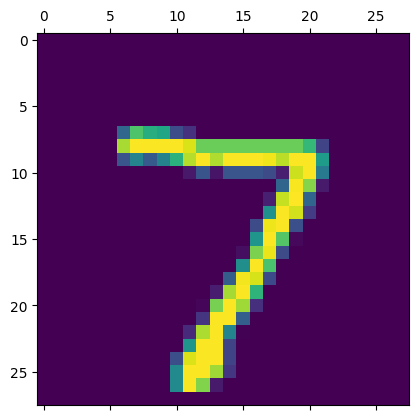

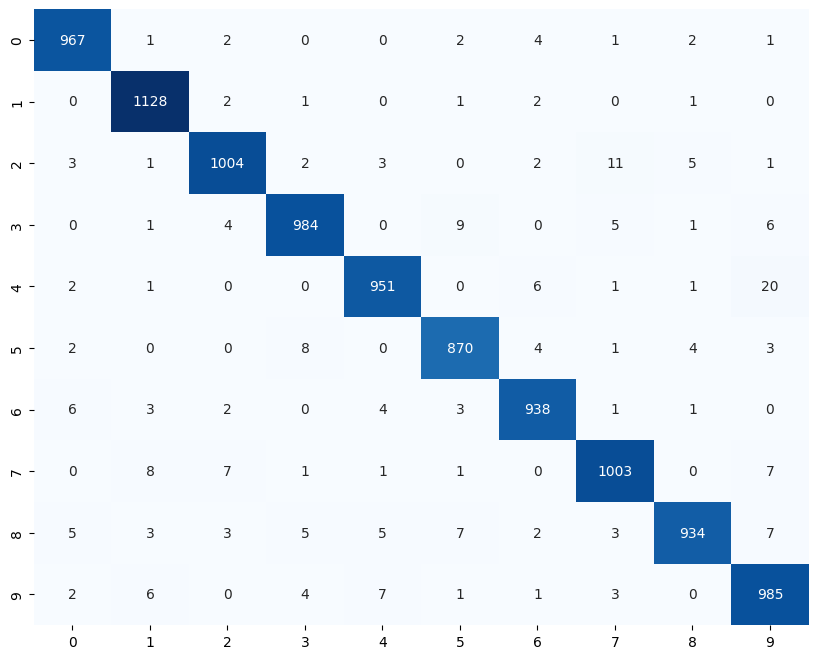

In [26]:
y_pred = model.predict(x_test) # probabilities
y_pred_labels = [np.argmax(i) for i in y_pred]
plt.matshow(x_test[0])
print("ytest[0] : ", y_test[0])
print("ypred[0] : ", y_pred_labels[0])

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,      
    fmt="d",             # Format numbers as integers
    cmap="Blues",        
    cbar=False,          
    xticklabels=range(10), 
    yticklabels=range(10)
)

# 3. Convolutional Neural Network
spatial feature extraction rather than a flattened array

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize the image data (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape the data to include a channel dimension (28, 28, 1) - Conv2D expects a 4D tensor
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels (0–9) since loss = categorical_crossentropy requires your labels to be explicit probability vectors. 
# If your target is the digit 7, it expects a 10-element array where index 7 is 1 and everything else is 0:

#sparse_categorical_crossentropy expects integer labels. If your target is the digit 7, it expects the label to simply be the integer 7. 
#Under the hood, TensorFlow automatically handles the math to map that single integer to your 10 output Softmax probabilities.

y_train = to_categorical(y_train, 10) 
y_test = to_categorical(y_test, 10)

In [29]:
# Sequential CNN model
model = Sequential()

# --- Layer 1: Convolutional Layer ---
# 32 filters, 3x3 kernel (filter), ReLU activation
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
# Output shape: (26, 26, 32), ie feature maps of 32 feature filters in the image (ie. 32 dimensions)

# --- Layer 2: Max Pooling Layer ---
# Reduces dimensionality using max in 2x2 shifting pools
model.add(MaxPooling2D(pool_size=(2, 2)))
# Output shape: (13, 13, 32)

# --- Layer 3: Flatten Layer ---
# Converts 2D feature maps to 1D vector
model.add(Flatten())
# Output shape: (13 * 13 * 32) = 5408

# --- Layer 4: Fully Connected (Dense) Layer ---
model.add(Dense(units=128, activation='relu'))

# --- Layer 5: Output Layer ---
# 10 neurons for 10 digit classes, softmax for probabilities
model.add(Dense(units=10, activation='softmax'))

# 6. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 7. Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

# 8. Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9500 - loss: 0.1715 - val_accuracy: 0.9789 - val_loss: 0.0623
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9831 - loss: 0.0554 - val_accuracy: 0.9810 - val_loss: 0.0539
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9883 - loss: 0.0375 - val_accuracy: 0.9860 - val_loss: 0.0414
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9919 - loss: 0.0266 - val_accuracy: 0.9861 - val_loss: 0.0435
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9851 - val_loss: 0.0475
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9851 - loss: 0.0475
Test accuracy: 0.9850999712944031


In [30]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,387,926 (5.29 MB)

In [6]:
# Function to build CNN model with variable filters

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


def create_cnn_model(num_filters):
    model = Sequential([
        Conv2D(filters=num_filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(units=128, activation='relu'),
        Dense(units=10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Test different filter sizes
filter_configs = [8, 16, 32, 64, 128]
results = []

for f in filter_configs:
    print(f"\n=== Training CNN with {f} filters ===")
    model = create_cnn_model(f)

    start_time = time.time()
    history = model.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0, validation_data=(x_test, y_test))
    elapsed_time = time.time() - start_time

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "Filters": f,
        "Train Accuracy (last epoch)": history.history['accuracy'][-1],
        "Validation Accuracy (last epoch)": history.history['val_accuracy'][-1],
        "Test Accuracy": test_acc,
        "Training Time (s)": round(elapsed_time, 2)
    })

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results)
print("\n=== Comparative Results Across Filter Configurations ===")
print(results_df.to_string(index=False))



=== Training CNN with 8 filters ===


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779826524.229685   36303 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



=== Training CNN with 16 filters ===

=== Training CNN with 32 filters ===

=== Training CNN with 64 filters ===

=== Training CNN with 128 filters ===

=== Comparative Results Across Filter Configurations ===
 Filters  Train Accuracy (last epoch)  Validation Accuracy (last epoch)  Test Accuracy  Training Time (s)
       8                     0.981300                            0.9799         0.9799              25.24
      16                     0.986167                            0.9819         0.9819              33.87
      32                     0.988183                            0.9814         0.9814              51.67
      64                     0.989267                            0.9852         0.9852              76.81
     128                     0.990500                            0.9866         0.9866             112.94


In [3]:
##### pre-processing input images for to be trained

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize (0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Define preprocessing filters
def apply_filter(data, filter_name):
    data_filtered = np.zeros_like(data)

    for i in range(data.shape[0]):
        img = data[i]
        if filter_name == "Original":
            data_filtered[i] = img
        elif filter_name == "Gaussian":
            data_filtered[i] = gaussian_filter(img, sigma=1)
        elif filter_name == "Sobel":
            sx = sobel(img, axis=0, mode='constant')
            sy = sobel(img, axis=1, mode='constant')
            data_filtered[i] = np.hypot(sx, sy)
        elif filter_name == "Laplacian":
            data_filtered[i] = laplace(img)
        elif filter_name == "Average":
            data_filtered[i] = cv2.blur(img, (3, 3))
        else:
            data_filtered[i] = img
    return data_filtered

# 4. One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 5. Function to create CNN
def create_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 6. Filter types to test
filter_types = ["Original", "Average", "Gaussian", "Sobel", "Laplacian"]

results = []

# 7. Train CNN on each filtered dataset
for ftype in filter_types:
    print(f"\n=== Training CNN with {ftype} filtered images ===")
    x_train_f = apply_filter(x_train, ftype)
    x_test_f = apply_filter(x_test, ftype)

    # Reshape for CNN
    x_train_f = x_train_f.reshape(-1, 28, 28, 1)
    x_test_f = x_test_f.reshape(-1, 28, 28, 1)

    # Create and train model
    model = create_cnn()
    start = time.time()
    history = model.fit(x_train_f, y_train, epochs=3, batch_size=64, verbose=0, validation_data=(x_test_f, y_test))
    duration = time.time() - start

    test_loss, test_acc = model.evaluate(x_test_f, y_test, verbose=0)

    results.append({
        "Filter Type": ftype,
        "Train Accuracy (last epoch)": round(history.history['accuracy'][-1], 4),
        "Validation Accuracy (last epoch)": round(history.history['val_accuracy'][-1], 4),
        "Test Accuracy": round(test_acc, 4),
        "Training Time (s)": round(duration, 2)
    })

# 8. Print comparison table
results_df = pd.DataFrame(results)
print("\n=== CNN Performance Comparison Across Filters ===")
print(results_df.to_string(index=False))



=== Training CNN with Original filtered images ===


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779862249.517946    4364 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



=== Training CNN with Average filtered images ===

=== Training CNN with Gaussian filtered images ===

=== Training CNN with Sobel filtered images ===

=== Training CNN with Laplacian filtered images ===

=== CNN Performance Comparison Across Filters ===
Filter Type  Train Accuracy (last epoch)  Validation Accuracy (last epoch)  Test Accuracy  Training Time (s)
   Original                       0.9884                            0.9815         0.9815              45.11
    Average                       0.9851                            0.9862         0.9862              23.93
   Gaussian                       0.9826                            0.9838         0.9838              25.52
      Sobel                       0.9886                            0.9840         0.9840              25.35
  Laplacian                       0.9852                            0.9774         0.9774              25.48


### 3.1 AlexNet, VGG-60, Resnet

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def AlexNet(input_shape=(224, 224, 3), num_classes=1000):
    model = models.Sequential([
        # --- Layer 1: Conv + MaxPool ---
        # 96 large 11x11 filters with a stride of 4 to rapidly downsample raw image spatial grids
        layers.Conv2D(filters=96, kernel_size=(11, 11), strides=4, padding='valid', 
                      activation='relu', input_shape=input_shape, name='conv_1'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='maxpool_1'),
        
        # --- Layer 2: Conv + MaxPool ---
        # 256 5x5 filters. Padding='same' preserves spatial dimensions before max-pooling
        layers.Conv2D(filters=256, kernel_size=(5, 5), strides=1, padding='same', 
                      activation='relu', name='conv_2'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='maxpool_2'),
        
        # --- Layer 3: Conv ---
        # 384 3x3 filters stacked directly without an intermediate pooling operation
        layers.Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', 
                      activation='relu', name='conv_3'),
        
        # --- Layer 4: Conv ---
        layers.Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', 
                      activation='relu', name='conv_4'),
        
        # --- Layer 5: Conv + MaxPool ---
        layers.Conv2D(filters=256, kernel_size=(3, 3), strides=1, padding='same', 
                      activation='relu', name='conv_5'),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='maxpool_5'),
        
        # --- Flattening Stage ---
        # Converts 3D spatial feature tensors into a flat 1D feature representation
        layers.Flatten(name='flatten'),
        
        # --- Layer 6: Fully Connected Dense ---
        layers.Dense(units=4096, activation='relu', name='fc_1'),
        layers.Dropout(rate=0.5, name='dropout_1'), # Reduces parameter co-dependency
        
        # --- Layer 7: Fully Connected Dense ---
        layers.Dense(units=4096, activation='relu', name='fc_2'),
        layers.Dropout(rate=0.5, name='dropout_2'),
        
        # --- Layer 8: Classification Head Output ---
        layers.Dense(units=num_classes, activation='softmax', name='output_classification')
    ], name='AlexNet_Architecture')
    
    return model

# Instantiate and verify structural graph boundaries
alexnet_model = AlexNet(input_shape=(224, 224, 3), num_classes=1000)
alexnet_model.summary()

'''
import tensorflow as tf
from tensorflow.keras import layers, models

class AlexNet(models.Model):
    def __init__(self, num_classes=1000):
        super(AlexNet, self).__init__()
        
        # --- Feature Extraction Block (Convolutional Backbone) ---
        self.features = models.Sequential([
            # Layer 1: Downsampling block for raw large-scale inputs
            layers.Conv2D(filters=96, kernel_size=(11, 11), strides=4, padding='valid', activation='relu', name='conv_1'),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='maxpool_1'),
            
            # Layer 2: Intermediate pattern grouping
            layers.Conv2D(filters=256, kernel_size=(5, 5), strides=1, padding='same', activation='relu', name='conv_2'),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='maxpool_2'),
            
            # Layers 3 & 4: Deep feature stacking without intermediate pooling
            layers.Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv_3'),
            layers.Conv2D(filters=384, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv_4'),
            
            # Layer 5: Final high-level part detector
            layers.Conv2D(filters=256, kernel_size=(3, 3), strides=1, padding='same', activation='relu', name='conv_5'),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='maxpool_5')
        ], name='feature_extractor')
        
        # --- Flattening Interface Stage ---
        self.flatten = layers.Flatten(name='flatten')
        
        # --- Classification Head Block (Dense Linear Reasoning) ---
        self.classifier = models.Sequential([
            # Layer 6
            layers.Dense(units=4096, activation='relu', name='fc_1'),
            layers.Dropout(rate=0.5, name='dropout_1'),
            
            # Layer 7
            layers.Dense(units=4096, activation='relu', name='fc_2'),
            layers.Dropout(rate=0.5, name='dropout_2'),
            
            # Layer 8: Output Probability Mapping
            layers.Dense(units=num_classes, activation='softmax', name='output_classification')
        ], name='classification_head')

    def call(self, inputs, training=False):
        # Move inputs sequentially through the underlying architectural blocks
        x = self.features(inputs)
        x = self.flatten(x)
        output = self.classifier(x, training=training) # Explicitly passes training state for Dropout stability
        return output

# =====================================================================
# MODEL INSTANTIATION AND FUNCTIONAL GRAPH BUILD
# =====================================================================
# Instantiate the custom network class
alexnet_model = AlexNet(num_classes=1000)

# Build the structural graph layout using dummy inputs to finalize tracking shapes
# Expected dimension format: (Batch Size, Height, Width, Channels)
alexnet_model.build(input_shape=(None, 224, 224, 3))

# Print summary schema parameters
alexnet_model.summary()
'''

/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "AlexNet_Architecture"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_5 (Conv2D)                 │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_5 (MaxPooling2D)        │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_classification (Dense)   │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,844,008 (193.95 MB)

 Trainable params: 50,844,008 (193.95 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# =====================================================================
# 1. DEFINE ALEXNET BY INHERITING FROM SEQUENTIAL
# =====================================================================
class AlexNetCIFAR(Sequential):
    def __init__(self, input_shape, num_classes):
        super().__init__()

        # --- Layer 1: Conv + MaxPool ---
        # Modified kernel from (11,11) s=4 to (3,3) s=1 to support 32x32 dimensions
        self.add(Conv2D(96, kernel_size=(3, 3), strides=1,
                        padding='same', activation='relu',
                        input_shape=input_shape,
                        kernel_initializer='he_normal'))
        self.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

        # --- Layer 2: Conv + MaxPool ---
        self.add(Conv2D(256, kernel_size=(5, 5), strides=1,
                        padding='same', activation='relu',
                        kernel_initializer='he_normal'))
        self.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')) 

        # --- Layers 3 & 4: Deep Conv Stacking ---
        self.add(Conv2D(384, kernel_size=(3, 3), strides=1,
                        padding='same', activation='relu',
                        kernel_initializer='he_normal'))

        self.add(Conv2D(384, kernel_size=(3, 3), strides=1,
                        padding='same', activation='relu',
                        kernel_initializer='he_normal'))

        # --- Layer 5: Conv + MaxPool ---
        self.add(Conv2D(256, kernel_size=(3, 3), strides=1,
                        padding='same', activation='relu',
                        kernel_initializer='he_normal'))
        self.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

        # --- Flattening & Linear Reasoning Block ---
        self.add(Flatten())
        
        # Layer 6
        self.add(Dense(4096, activation='relu', kernel_initializer='he_normal'))
        self.add(Dropout(0.5))  # Critical regularization to mitigate parameter overfitting
        
        # Layer 7
        self.add(Dense(4096, activation='relu', kernel_initializer='he_normal'))
        self.add(Dropout(0.5))

        # Layer 8: Output Softmax Classification Head
        self.add(Dense(num_classes, activation='softmax'))

        # Compile the pipeline graph
        self.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Lower LR for stable convergence
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

# =====================================================================
# 2. DATA PREPROCESSING CORNER (CIFAR-10)
# =====================================================================
print("Loading CIFAR-10 Dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Limit dataset size slightly for quick execution testing if running locally
x_train, y_train = x_train[:10000], y_train[:10000]
x_test, y_test = x_test[:2000], y_test[:2000]

# Normalize pixel states into a continuous mathematical range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert target integer vectors into one-hot encoded label matrices
num_classes = 10
Fla

# =====================================================================
# 3. INITIALIZE AND TRAIN THE MODEL SYSTEM
# =====================================================================
input_shape = (32, 32, 3)
model = AlexNetCIFAR(input_shape=input_shape, num_classes=num_classes)

# Display structural summaries of the sequential stack execution track
model.summary()

print("\nTraining Adjusted AlexNet on CIFAR-10 Matrix Layers...")
history = model.fit(
    x_train, y_train,
    epochs=4,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# Evaluate performance markers across unseen test boundaries
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Verified Test Accuracy: {test_acc * 100:.2f}%")

I0000 00:00:1779993802.777343   48426 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779993802.777733   48426 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779993802.815211   48426 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779993803.732640   48426 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Loading CIFAR-10 Dataset...


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779993806.111151   48426 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "alex_net_cifar"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,318,538 (142.36 MB)

 Trainable params: 37,318,538 (142.36 MB)

 Non-trainable params: 0 (0.00 B)


Training Adjusted AlexNet on CIFAR-10 Matrix Layers...
Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 128s 809ms/step - accuracy: 0.2669 - loss: 2.0146 - val_accuracy: 0.4045 - val_loss: 1.6847
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 138s 879ms/step - accuracy: 0.3978 - loss: 1.6454 - val_accuracy: 0.4235 - val_loss: 1.5761
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 143s 912ms/step - accuracy: 0.4561 - loss: 1.4909 - val_accuracy: 0.4790 - val_loss: 1.4537
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 140s 894ms/step - accuracy: 0.5059 - loss: 1.3492 - val_accuracy: 0.5110 - val_loss: 1.3363

Final Verified Test Accuracy: 51.10%


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# =====================================================================
# 1. INITIALIZE AND FORCE GRAPH COMPILATION BOUNDARIES
# =====================================================================
input_shape = (32, 32, 3)
num_classes = 10

# Instantiate your exact class with the 10-class limit constraint
model = AlexNetCIFAR(input_shape=input_shape, num_classes=num_classes)

# Explicitly build the sequential layer variables to freeze output tensor dimensions
model.build(input_shape=(None, 32, 32, 3))

# =====================================================================
# 2. LOCAL IMAGE PREPROCESSING CORNER
# =====================================================================
img_path = "./public/airplane.jpg"

# Squeezing the spatial resolution to match your input_shape
img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img)
img_normalized = img_array.astype('float32') / 255.0
img_batch = np.expand_dims(img_normalized, axis=0)  # Shape: (1, 32, 32, 3)

# =====================================================================
# 3. RUN INFERENCE FORWARD PASS
# =====================================================================
print("Passing your local image tensor matrix through AlexNet layers...")
raw_predictions = model.predict(img_batch, verbose=0)

# Check matrix dimension consistency output tracker
print(f"Model Output Matrix Shape: {raw_predictions.shape} -> Bound to: (1, 10)")

# =====================================================================
# 4. SAFE DECODE VIA CIFAR-10 CLASS LABELS
# =====================================================================
cifar10_labels = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Find the array index containing the maximum Softmax activation score
predicted_index = np.argmax(raw_predictions[0])
predicted_label = cifar10_labels[predicted_index]
confidence_score = raw_predictions[0][predicted_index]

print("\n=== CUSTOM ALEXNET CLASSIFICATION ===")
print(f"Predicted Class String : {predicted_label}")
print(f"Softmax Activation Peak: {confidence_score * 100:.2f}%")

Passing your local image tensor matrix through AlexNet layers...
Model Output Matrix Shape: (1, 10) -> Bound to: (1, 10)

=== CUSTOM ALEXNET CLASSIFICATION ===
Predicted Class String : frog
Softmax Activation Peak: 35.02%


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

# =====================================================================
# 1. LOAD A PRE-TRAINED IMAGENET MODEL
# =====================================================================
# We instantiate a 50-layer Residual Network pre-loaded with weights 
# trained on over 1 million real-world ImageNet photos.
print("Loading pre-trained ResNet50 model weights...")
model = ResNet50(weights='imagenet')

# =====================================================================
# 2. FETCH OR DEFINE A REAL IMAGE
# =====================================================================
# Downloading a sample public domain airplane image from the web

'''
img_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/aeroplane.jpg"
img_path = tf.keras.utils.get_file("sample_airplane.jpg", img_url)
'''

# NOTE: To classify your own personal image, just comment out the two lines 
# above and replace it with your local file path like this:
# img_path = "path/to/your/my_airplane_photo.jpg"

# =====================================================================
# 3. MATRIX PREPROCESSING CORNER
# =====================================================================
# Step A: Load the image file and physically resize it to a 224x224 grid 
# to match the fixed spatial dimensions expected by the input layer matrix.
img = image.load_img("./public/airplane.jpg", target_size=(224, 224))

# Step B: Convert the visual image object into a 3D NumPy float array matrix.
# Resulting array shape: (Height, Width, Channels) -> (224, 224, 3)
img_array = image.img_to_array(img)

# Step C: Expand dimensions to simulate a batch matrix wrapper. 
# Keras models expect a 4D tensor tracking: (Batch Size, H, W, Channels)
# This turns our single image matrix array from shape (224, 224, 3) to (1, 224, 224, 3)
img_batch = np.expand_dims(img_array, axis=0)

# Step D: Apply ImageNet specific channel-wise color center zero-biasing.
# This scales/normalizes the pixel integers exactly how ResNet was originally optimized.
processed_img = preprocess_input(img_batch)

# =====================================================================
# 4. RUN INFERENCE FORWARD PASS
# =====================================================================
print("Running forward pass through model layers...")
predictions = model.predict(processed_img, verbose=0)

# =====================================================================
# 5. DECODE AND PRINT RESULTS
# =====================================================================
# Convert the raw 1000-unit output Softmax probability matrix back into 
# human-readable label strings. We grab the top 3 highest scoring classes.
decoded_results = decode_predictions(predictions, top=3)[0]

print("\n=== CLASSIFICATION RESULTS ===")
for i, (imagenet_id, label, probability) in enumerate(decoded_results):
    print(f"{i+1}. Predicted Class: {label:<15} | Confidence: {probability * 100:.2f}%")

Loading pre-trained ResNet50 model weights...
102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Running forward pass through model layers...
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

=== CLASSIFICATION RESULTS ===
1. Predicted Class: airliner        | Confidence: 92.55%
2. Predicted Class: wing            | Confidence: 6.85%
3. Predicted Class: warplane        | Confidence: 0.41%


## 3. Recurrent Neural Network